In [1]:
import numpy as np
import pandas as pd
import torch

from datasets import load_dataset, concatenate_datasets
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)
import evaluate

In [2]:
ds_toxigen = load_dataset(
    "toxigen/toxigen-data",
    split="train"
)

def preprocess_toxigen(example):
    label = 1 if example["toxicity_human"] >= 3 else 0
    return {"text": example["text"], "label": label}

ds_toxigen = ds_toxigen.map(
    preprocess_toxigen,
    remove_columns=ds_toxigen.column_names
)

print(ds_toxigen)


Dataset({
    features: ['text', 'label'],
    num_rows: 8960
})


In [3]:
ds_multi_en = load_dataset(
    "textdetox/multilingual_toxicity_dataset",
    split="en"
)

ds_multi_ru = load_dataset(
    "textdetox/multilingual_toxicity_dataset",
    split="ru"
)

def preprocess_multi(example):
    return {"text": example["text"], "label": example["toxic"]}

ds_multi_en = ds_multi_en.map(
    preprocess_multi,
    remove_columns=ds_multi_en.column_names
)

ds_multi_ru = ds_multi_ru.map(
    preprocess_multi,
    remove_columns=ds_multi_ru.column_names
)

ds_multi = concatenate_datasets([ds_multi_en, ds_multi_ru])

print(ds_multi)


Dataset({
    features: ['text', 'label'],
    num_rows: 10000
})


In [4]:
ds_ru1 = load_dataset(
    "Xeonil/ru-merged-toxic-comments",
    split="train"
)

def preprocess_ru1(example):
    return {"text": example["text"], "label": example["target"]}

ds_ru1 = ds_ru1.map(
    preprocess_ru1,
    remove_columns=ds_ru1.column_names
)

print(ds_ru1)


Dataset({
    features: ['text', 'label'],
    num_rows: 271410
})


In [5]:
ds_ru2 = load_dataset(
    "AlexSham/Toxic_Russian_Comments",
    split="train"
)

def preprocess_ru2(example):
    return {"text": example["text"], "label": example["label"]}

ds_ru2 = ds_ru2.map(
    preprocess_ru2,
    remove_columns=ds_ru2.column_names
)

print(ds_ru2)


Dataset({
    features: ['text', 'label'],
    num_rows: 223461
})


In [6]:
full_dataset = concatenate_datasets([
    ds_toxigen,
    ds_multi,
    ds_ru1,
    ds_ru2
])

full_dataset = full_dataset.shuffle(seed=42)
full_dataset = full_dataset.train_test_split(test_size=0.1)

print(full_dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 462447
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 51384
    })
})


In [7]:
train_df = full_dataset['train'].to_pandas()
test_df = full_dataset['test'].to_pandas()

df = pd.concat([train_df, test_df], axis=0)

# EDA

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

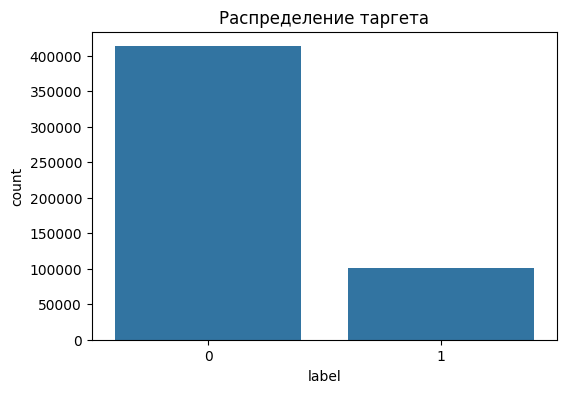

In [9]:
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df)
plt.title('Распределение таргета')
plt.show()

In [10]:
df['label'].value_counts()

label
0    413314
1    100517
Name: count, dtype: int64

In [11]:
df['label'].value_counts(normalize=True)

label
0    0.804377
1    0.195623
Name: proportion, dtype: float64

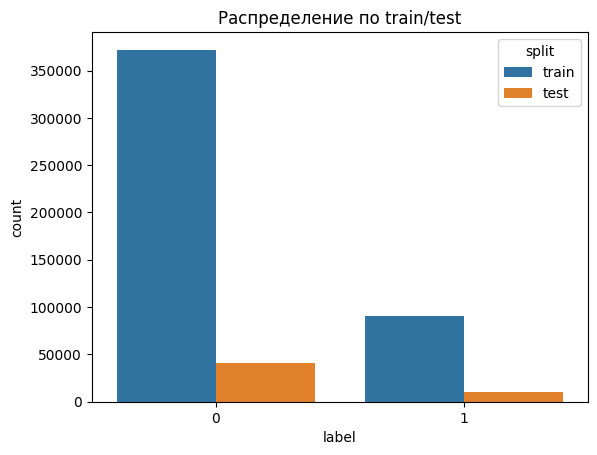

In [12]:
train_df['split'] = 'train'
test_df['split'] = 'test'

temp = pd.concat([train_df, test_df])

sns.countplot(data=temp, x='label', hue='split')
plt.title('Распределение по train/test')
plt.show()

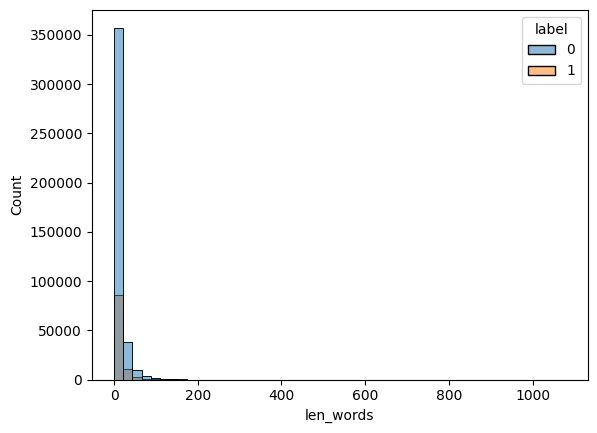

In [13]:
df['len_words'] = df['text'].apply(lambda x: len(x.split()))

sns.histplot(data=df, x='len_words', hue='label', bins=50)
plt.show()

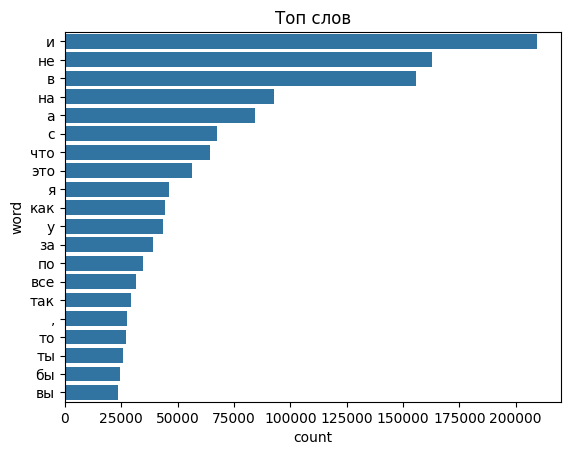

In [14]:
from collections import Counter

all_words = " ".join(df['text']).lower().split()
counter = Counter(all_words)

top_words = pd.DataFrame(counter.most_common(20), columns=['word','count'])

sns.barplot(data=top_words, x='count', y='word')
plt.title('Топ слов')
plt.show()

In [15]:
for t in df['label'].unique():
    words = " ".join(df[df['label']==t]['text']).lower().split()
    counter = Counter(words)
    print(f"\nКласс {t}")
    print(counter.most_common(10))


Класс 1
[('и', 42672), ('не', 31480), ('в', 26770), ('на', 19897), ('а', 17031), ('ты', 14408), ('что', 13818), ('с', 10478), ('это', 10431), ('как', 10087)]

Класс 0
[('и', 166890), ('не', 131289), ('в', 129147), ('на', 72818), ('а', 67515), ('с', 56940), ('что', 50347), ('это', 45838), ('я', 38648), ('у', 35838)]


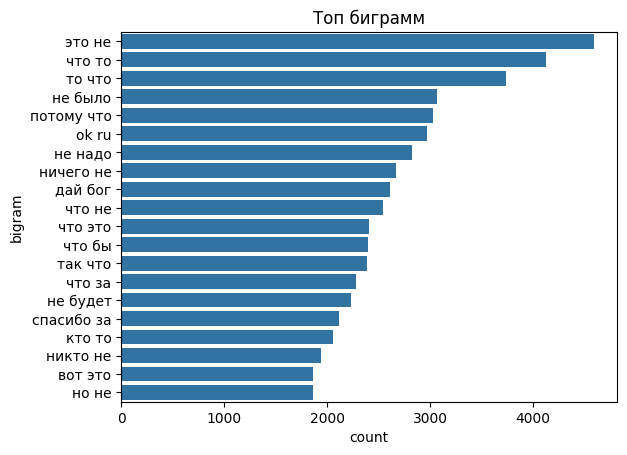

In [16]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(ngram_range=(2,2), max_features=20)
X_bi = cv.fit_transform(df['text'])

bigrams = pd.DataFrame({
    'bigram': cv.get_feature_names_out(),
    'count': X_bi.sum(axis=0).A1
}).sort_values(by='count', ascending=False)

sns.barplot(data=bigrams, x='count', y='bigram')
plt.title('Топ биграмм')
plt.show()

# Бейзлайн

In [17]:
import pandas as pd
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import seaborn as sns
import matplotlib.pyplot as plt

In [18]:
X_train = train_df['text']
y_train = train_df['label']

X_test = test_df['text']
y_test = test_df['label']

In [19]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('model', LogisticRegression(max_iter=2000))
])

In [20]:
from sklearn.model_selection import GridSearchCV

params = {
    'tfidf__max_features': [5000, 10000],
    'tfidf__ngram_range': [(1,1), (1,2)],
    'tfidf__min_df': [3, 5],

    'model__C': [0.1, 1, 5],
    'model__class_weight': [None, 'balanced']
}

grid = GridSearchCV(
    pipeline,
    params,
    cv=3,
    scoring='f1',  # из-за дисбаланса
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV score:", grid.best_score_)

Fitting 3 folds for each of 48 candidates, totalling 144 fits
Best params: {'model__C': 5, 'model__class_weight': None, 'tfidf__max_features': 10000, 'tfidf__min_df': 3, 'tfidf__ngram_range': (1, 1)}
Best CV score: 0.8398649552066648


In [21]:
best_model = grid.best_estimator_

In [22]:
y_pred = best_model.predict(X_test)

In [23]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

print("\nClassification report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9435427370387669
Precision: 0.9312958729394778
Recall: 0.7686196623634558
F1: 0.8421739840052228

Classification report:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97     41314
           1       0.93      0.77      0.84     10070

    accuracy                           0.94     51384
   macro avg       0.94      0.88      0.90     51384
weighted avg       0.94      0.94      0.94     51384



In [24]:
y_proba = best_model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_proba)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.9640917388129633


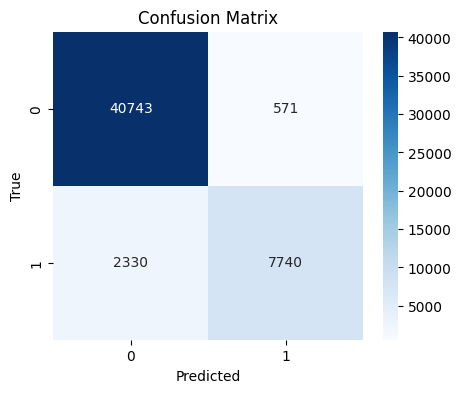

In [25]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Обучение

In [26]:
MODEL_NAME = "xlm-roberta-base"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [27]:
def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

tokenized = full_dataset.map(tokenize, batched=True)
tokenized = tokenized.remove_columns(["text"])
tokenized.set_format("torch")

Map:   0%|          | 0/462447 [00:00<?, ? examples/s]

Map:   0%|          | 0/51384 [00:00<?, ? examples/s]

In [28]:
accuracy = evaluate.load("accuracy")
f1 = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    return {
        "accuracy": accuracy.compute(
            predictions=preds,
            references=labels
        )["accuracy"],
        "f1": f1.compute(
            predictions=preds,
            references=labels
        )["f1"]
    }

In [29]:
training_args = TrainingArguments(
    output_dir="./toxic_model",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_steps=100,
    report_to="none"
)

In [30]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized["train"],
    eval_dataset=tokenized["test"],
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

In [31]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.104288,0.112806,0.969465,0.924455
2,0.074399,0.086967,0.979235,0.946631
3,0.051168,0.082806,0.982310,0.954891


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=86709, training_loss=0.09052155541253729, metrics={'train_runtime': 8559.9056, 'train_samples_per_second': 162.074, 'train_steps_per_second': 10.13, 'total_flos': 9.125618866354944e+16, 'train_loss': 0.09052155541253729, 'epoch': 3.0})

In [32]:
def predict_toxicity(text: str):
    model.eval()

    device = next(model.parameters()).device

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    probs = torch.softmax(outputs.logits, dim=1)

    return {
        "non_toxic": probs[0][0].item(),
        "toxic": probs[0][1].item()
    }

In [33]:
trainer.save_model("./toxic_model")
tokenizer.save_pretrained("./toxic_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./toxic_model\\tokenizer_config.json', './toxic_model\\tokenizer.json')